## 1. Loding Data

This notebook performs IPL cricket analysis and prediction using only Pandas, NumPy, Matplotlib, Seaborn and Plotly.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as tls

sns.set_theme(style='whitegrid')


In [2]:
mat = pd.read_csv("../data/matches.csv")
dev = pd.read_csv("../data/deliveries.csv")

## 2. Analyze Data Set

In [3]:
mat.head()

,id,season,city,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin_type,result_margin,team1_score,team2_score,eliminator,umpire1,umpire2
0,1,2016,Mohali,"Punjab Cricket Association Stadium, Mohali",Royal Challengers Bengaluru,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,normal,runs,67,103,170,N,A Deshmukh,J Madanagopal
1,2,2016,Delhi,"Arun Jaitley Stadium, Delhi",Punjab Kings,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,normal,runs,13,170,183,N,V Kulkarni,P Reiffel
2,3,2016,Hyderabad,"Rajiv Gandhi Intl. Stadium, Hyderabad",Punjab Kings,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,normal,wickets,6,194,196,N,K Ananthapadmanabhan,V Kulkarni
3,4,2016,Lucknow,"BRSABV Ekana Stadium, Lucknow",Delhi Capitals,Sunrisers Hyderabad,Delhi Capitals,bat,Delhi Capitals,normal,runs,107,194,87,N,P Reiffel,C Shamshuddin
4,5,2016,Mohali,"Punjab Cricket Association Stadium, Mohali",Mumbai Indians,Rajasthan Royals,Rajasthan Royals,bat,Mumbai Indians,normal,wickets,6,206,200,N,K Ananthapadmanabhan,A Deshmukh


In [4]:
mat.shape

(476, 17)

In [5]:
mat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  476 non-null    int64 
 1   season              476 non-null    int64 
 2   city                476 non-null    object
 3   venue               476 non-null    object
 4   team1               476 non-null    object
 5   team2               476 non-null    object
 6   toss_winner         476 non-null    object
 7   toss_decision       476 non-null    object
 8   winner              476 non-null    object
 9   result              476 non-null    object
 10  result_margin_type  476 non-null    object
 11  result_margin       476 non-null    int64 
 12  team1_score         476 non-null    int64 
 13  team2_score         476 non-null    int64 
 14  eliminator          476 non-null    object
 15  umpire1             476 non-null    object
 16  umpire2             476 no

In [6]:
mat.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,476.0,NaN,NaN,NaN,238.5,137.553626,1.0,119.75,238.5,357.25,476.0
season,476.0,NaN,NaN,NaN,2019.676471,2.33787,2016.0,2018.0,2020.0,2022.0,2023.0
city,476,10,Hyderabad,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
venue,476,10,"Rajiv Gandhi Intl. Stadium, Hyderabad",57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team1,476,9,Mumbai Indians,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team2,476,9,Sunrisers Hyderabad,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_winner,476,10,Mumbai Indians,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_decision,476,2,field,247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
winner,476,10,Royal Challengers Bengaluru,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
result,476,2,normal,467,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
dev.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,bowler,batsman_runs,extra_runs,total_runs,is_wicket,dismissal_kind,player_dismissed
0,1,1,Sunrisers Hyderabad,Royal Challengers Bengaluru,1,1,A Mehta,M Mehta,0,0,0,1,caught,A Mehta
1,1,1,Sunrisers Hyderabad,Royal Challengers Bengaluru,1,2,D Doyle,M Mehta,0,0,0,1,bowled,D Doyle
2,1,1,Sunrisers Hyderabad,Royal Challengers Bengaluru,1,3,K Nair,M Mehta,0,0,0,0,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bengaluru,1,4,K Nair,M Mehta,2,0,2,0,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bengaluru,1,5,K Nair,M Mehta,0,0,0,0,NaN,NaN


In [8]:
dev.shape

(107019, 14)

In [9]:
dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107019 entries, 0 to 107018
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          107019 non-null  int64 
 1   inning            107019 non-null  int64 
 2   batting_team      107019 non-null  object
 3   bowling_team      107019 non-null  object
 4   over              107019 non-null  int64 
 5   ball              107019 non-null  int64 
 6   batsman           107019 non-null  object
 7   bowler            107019 non-null  object
 8   batsman_runs      107019 non-null  int64 
 9   extra_runs        107019 non-null  int64 
 10  total_runs        107019 non-null  int64 
 11  is_wicket         107019 non-null  int64 
 12  dismissal_kind    6379 non-null    object
 13  player_dismissed  6379 non-null    object
dtypes: int64(8), object(6)
memory usage: 11.4+ MB


In [10]:
dev.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
match_id,107019.0,NaN,NaN,NaN,239.048832,137.139325,1.0,121.0,240.0,358.0,476.0
inning,107019.0,NaN,NaN,NaN,1.482438,0.499694,1.0,1.0,1.0,2.0,2.0
batting_team,107019,10,Punjab Kings,12836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bowling_team,107019,10,Mumbai Indians,12865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
over,107019.0,NaN,NaN,NaN,10.011989,5.599025,1.0,5.0,10.0,15.0,20.0
ball,107019.0,NaN,NaN,NaN,3.489932,1.707782,1.0,2.0,3.0,5.0,6.0
batsman,107019,233,R Ghosh,2449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bowler,107019,183,A Kulkarni,2836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
batsman_runs,107019.0,NaN,NaN,NaN,1.571282,1.955176,0.0,0.0,1.0,3.0,6.0
extra_runs,107019.0,NaN,NaN,NaN,0.026388,0.19672,0.0,0.0,0.0,0.0,2.0


In [11]:
print("Missing values in matches:")
print(mat.isnull().sum())

Missing values in matches:
id                    0
season                0
city                  0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin_type    0
result_margin         0
team1_score           0
team2_score           0
eliminator            0
umpire1               0
umpire2               0
dtype: int64


In [12]:
print("Missing values in deliveries:")
print(dev.isnull().sum())

Missing values in deliveries:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
bowler                   0
batsman_runs             0
extra_runs               0
total_runs               0
is_wicket                0
dismissal_kind      100640
player_dismissed    100640
dtype: int64


## 3. Data Cleaning

In [13]:
# Fill missing text values only where they are useful for analysis
mat["city"] = mat["city"].fillna("Unknown")
mat["winner"] = mat["winner"].fillna("No Result")
mat["toss_winner"] = mat["toss_winner"].fillna("Unknown")
mat["toss_decision"] = mat["toss_decision"].fillna("Unknown")
mat["eliminator"] = mat["eliminator"].fillna("N")
dev["dismissal_kind"] = dev["dismissal_kind"].fillna("Not Out")

In [14]:
# Convert the match id to the same name used in deliveries
mat = mat.rename(columns={"id": "match_id"})
mat["season"] = mat["season"].astype(str)
mat["result_margin"] = pd.to_numeric(mat["result_margin"], errors="coerce")
# Add season information to each delivery for season-wise player analysis
dev = dev.merge(mat[["match_id", "season"]], on="match_id", how="left")

In [15]:
# Quick check after cleaning
print("Matches shape:", mat.shape)
print("Deliveries shape:", dev.shape)
print("Missing winner values:", mat["winner"].isna().sum())

Matches shape: (476, 17)
Deliveries shape: (107019, 15)
Missing winner values: 0


## 4. Basic Match Statistics

In [16]:
print("City with most matches:")
print(mat["city"].value_counts().head(1))

print("\nTeam with most wins:")
print(mat["winner"].value_counts().head(1))

print("\nTop run scorer in deliveries:")
print(dev.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(1))

City with most matches:
city
Hyderabad    57
Name: count, dtype: int64

Team with most wins:
winner
Royal Challengers Bengaluru    71
Name: count, dtype: int64

Top run scorer in deliveries:
batsman
R Ghosh    3761
Name: batsman_runs, dtype: int64


In [17]:
print("Most frequent Umpire 1:")
print(mat["umpire1"].value_counts().head(1))

print("\nMost frequent Umpire 2:")
print(mat["umpire2"].value_counts().head(1))

Most frequent Umpire 1:
umpire1
V Kulkarni    59
Name: count, dtype: int64

Most frequent Umpire 2:
umpire2
C Shamshuddin    69
Name: count, dtype: int64


In [18]:
print("Matches played in each season:")
print(mat["season"].value_counts().sort_index())

Matches played in each season:
season
2016    56
2017    56
2018    56
2019    56
2020    56
2021    56
2022    70
2023    70
Name: count, dtype: int64


## 5. Data Visualization

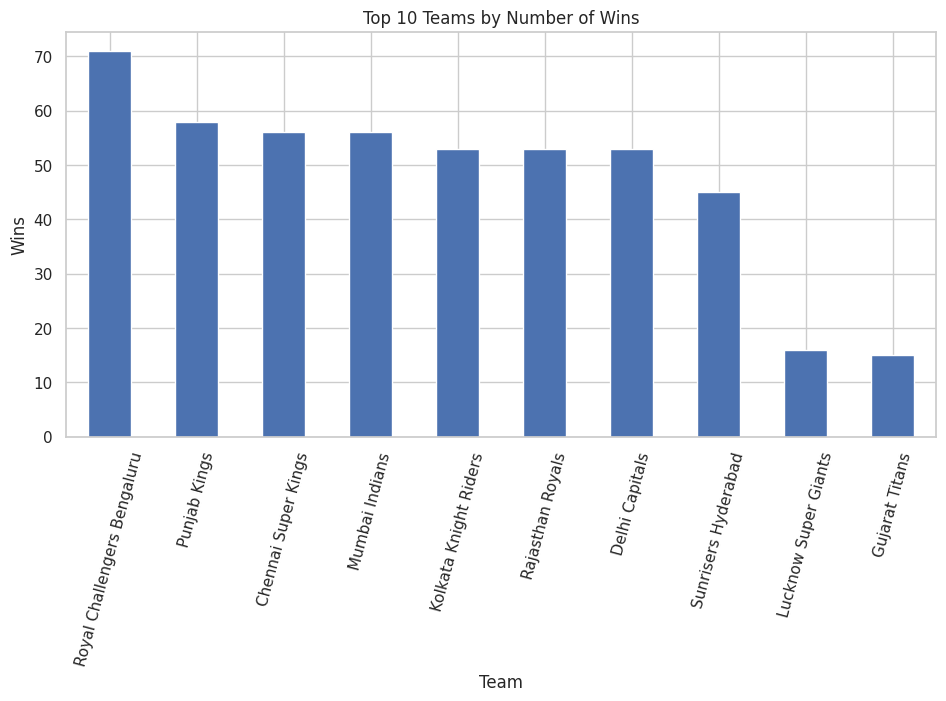

In [19]:
plt.figure(figsize=(10,5))
mat["winner"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Teams by Number of Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=75)
plt.show()

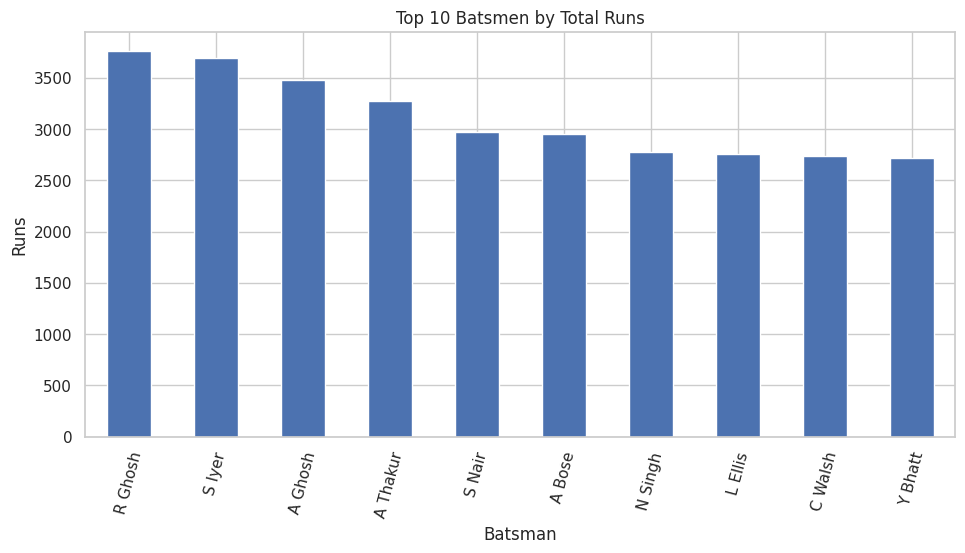

In [20]:
top_bat_awards = dev.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_bat_awards.plot(kind="bar")
plt.title("Top 10 Batsmen by Total Runs")
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.xticks(rotation=75)
plt.show()

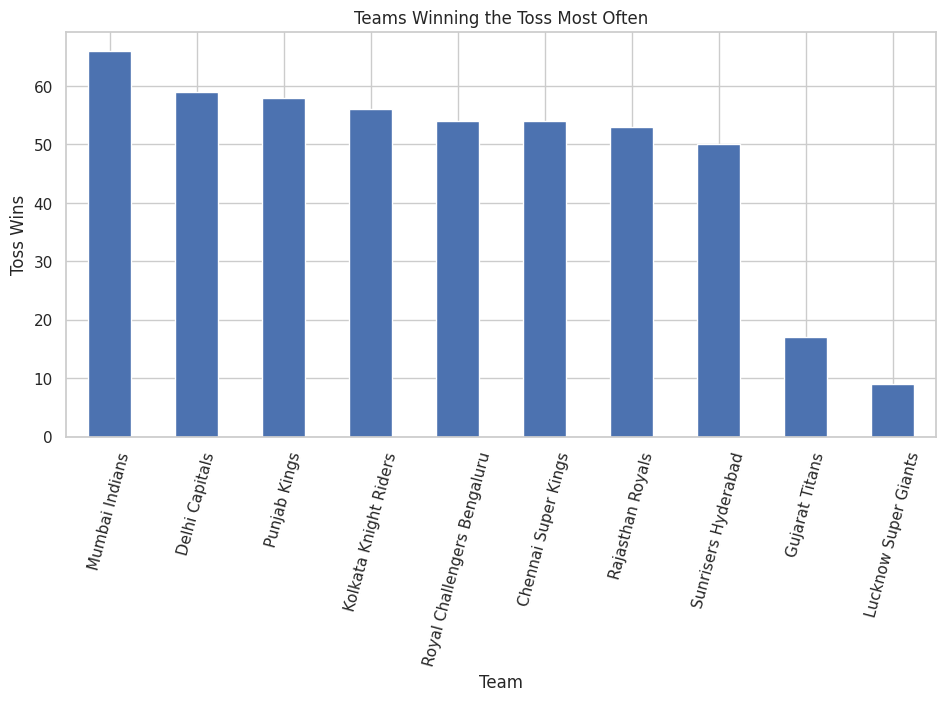

In [21]:
toss_counts = mat["toss_winner"].value_counts().head(10)
plt.figure(figsize=(10,5))
toss_counts.plot(kind="bar")
plt.title("Teams Winning the Toss Most Often")
plt.xlabel("Team")
plt.ylabel("Toss Wins")
plt.xticks(rotation=75)
plt.show()

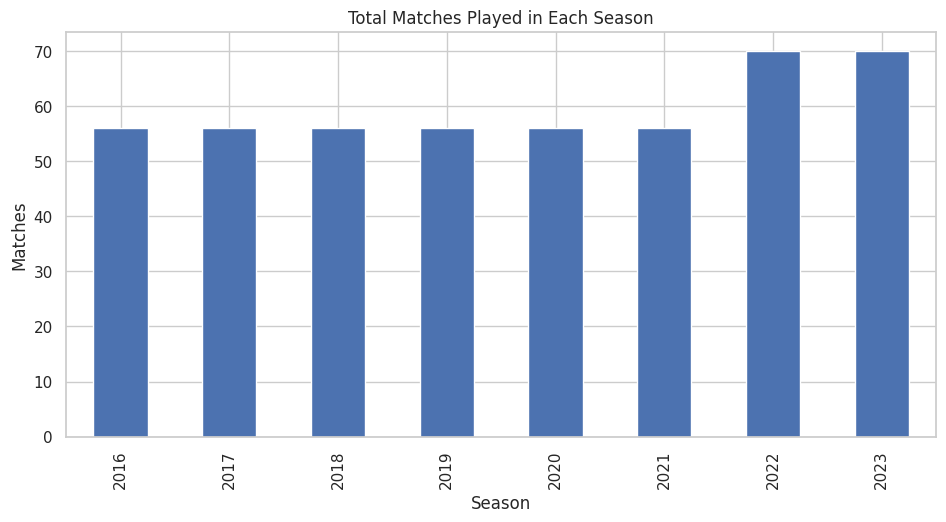

In [22]:
season_counts = mat["season"].value_counts().sort_index()
plt.figure(figsize=(10,5))
season_counts.plot(kind="bar")
plt.title("Total Matches Played in Each Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.xticks(rotation=90)
plt.show()

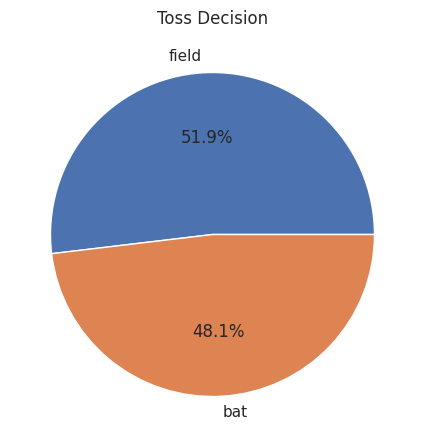

In [23]:
plt.figure(figsize=(10,5))
mat["toss_decision"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Toss Decision")
plt.ylabel("")
plt.show()

## 6. Team and Toss Analysis

In [24]:
toss_and_match = mat[mat["toss_winner"] == mat["winner"]]
print("Matches where toss winner also won:", len(toss_and_match))
print("Toss winner success percentage:",
      round(len(toss_and_match) / len(mat) * 100, 2), "%")

Matches where toss winner also won: 255
Toss winner success percentage: 53.57 %


In [25]:
toss_result = mat.groupby("toss_decision").apply(
    lambda x: pd.Series({
        "matches": len(x),
        "toss_won_and_match_won": (x["toss_winner"] == x["winner"]).sum()
    }),
    include_groups=False
)
toss_result["success_rate_%"] = (
    toss_result["toss_won_and_match_won"] / toss_result["matches"] * 100
).round(2)
toss_result

,matches,toss_won_and_match_won,success_rate_%
toss_decision,,,
bat,229,132,57.64
field,247,123,49.80


## 7. Season-wise Winner Analysis

In [26]:
season_winners = mat.groupby(["season", "winner"]).size().reset_index(name="wins")
season_winners = season_winners.sort_values(["season", "wins"], ascending=[True, False])
season_winners.head(10)

,season,winner,wins
1,2016,Delhi Capitals,10
2,2016,Kolkata Knight Riders,9
6,2016,Royal Challengers Bengaluru,9
0,2016,Chennai Super Kings,7
3,2016,Mumbai Indians,7
5,2016,Rajasthan Royals,7
4,2016,Punjab Kings,4
7,2016,Sunrisers Hyderabad,3
12,2017,Punjab Kings,9
14,2017,Royal Challengers Bengaluru,9


In [27]:
winner_by_year = season_winners.loc[season_winners.groupby("season")["wins"].idxmax()]
winner_by_year = winner_by_year[["season", "winner", "wins"]].reset_index(drop=True)
winner_by_year

,season,winner,wins
0,2016,Delhi Capitals,10
1,2017,Punjab Kings,9
2,2018,Royal Challengers Bengaluru,10
3,2019,Punjab Kings,10
4,2020,Chennai Super Kings,9
5,2021,Kolkata Knight Riders,9
6,2022,Lucknow Super Giants,10
7,2023,Royal Challengers Bengaluru,12


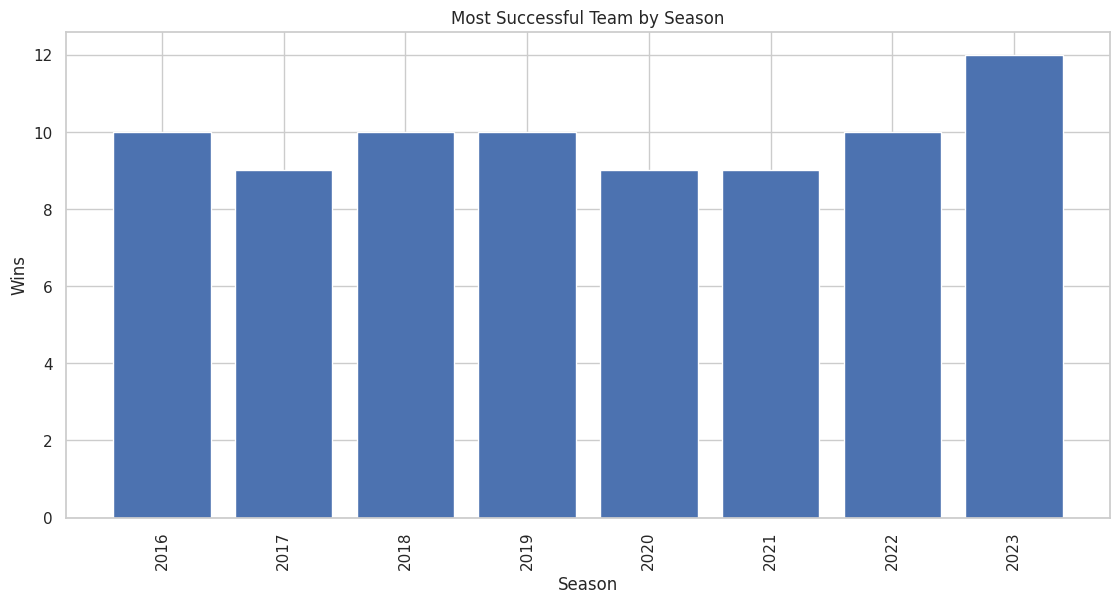

In [28]:
plt.figure(figsize=(12,6))
plt.bar(winner_by_year["season"], winner_by_year["wins"])
plt.title("Most Successful Team by Season")
plt.xlabel("Season")
plt.ylabel("Wins")
plt.xticks(rotation=90)
plt.show()

## 8. Super Over Analysis

In [29]:
super_over_matches = mat[mat["eliminator"].str.upper() == "Y"]
print("Number of Super Over matches:", len(super_over_matches))
super_over_matches[["season", "team1", "team2", "winner", "eliminator"]].head(20)

Number of Super Over matches: 9


,season,team1,team2,winner,eliminator
14,2016,Rajasthan Royals,Sunrisers Hyderabad,Rajasthan Royals,Y
80,2017,Chennai Super Kings,Punjab Kings,Punjab Kings,Y
213,2019,Delhi Capitals,Sunrisers Hyderabad,Sunrisers Hyderabad,Y
281,2021,Mumbai Indians,Delhi Capitals,Mumbai Indians,Y
394,2022,Mumbai Indians,Gujarat Titans,Gujarat Titans,Y
397,2022,Chennai Super Kings,Punjab Kings,Punjab Kings,Y
419,2023,Chennai Super Kings,Rajasthan Royals,Chennai Super Kings,Y
429,2023,Royal Challengers Bengaluru,Delhi Capitals,Delhi Capitals,Y
466,2023,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,Y


In [30]:
print("Super Over wins by team:")
print(super_over_matches["winner"].value_counts().head(10))

Super Over wins by team:
winner
Punjab Kings           2
Sunrisers Hyderabad    2
Rajasthan Royals       1
Mumbai Indians         1
Gujarat Titans         1
Chennai Super Kings    1
Delhi Capitals         1
Name: count, dtype: int64


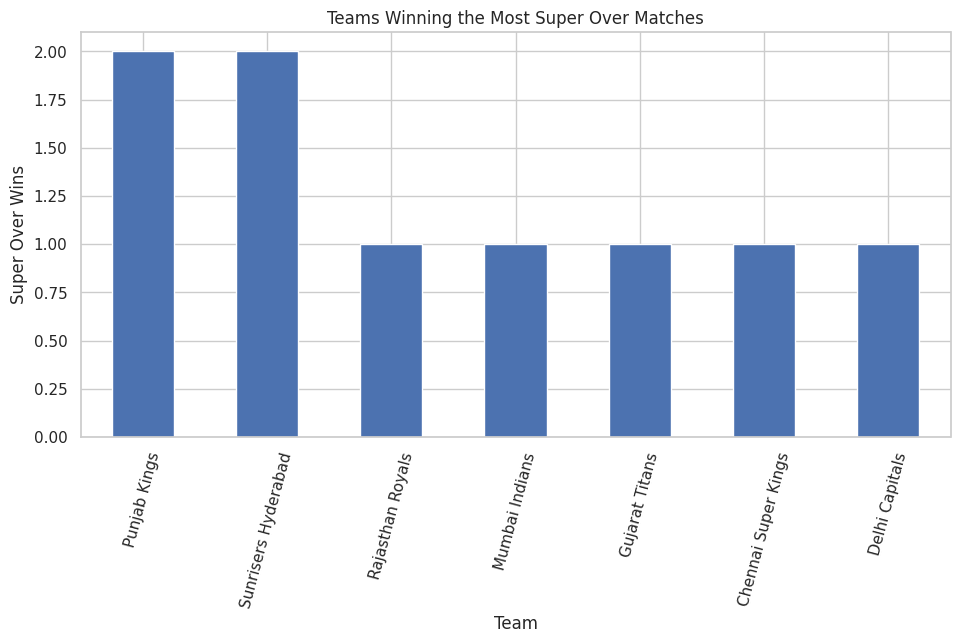

In [31]:
if len(super_over_matches) > 0:
    plt.figure(figsize=(10,5))
    super_over_matches["winner"].value_counts().plot(kind="bar")
    plt.title("Teams Winning the Most Super Over Matches")
    plt.xlabel("Team")
    plt.ylabel("Super Over Wins")
    plt.xticks(rotation=75)
    plt.show()

## 9. High Scoring Matches (200+ Runs)

In [32]:
high_scoring = mat[(mat["team1_score"] >= 200) | (mat["team2_score"] >= 200)].copy()
print("Number of matches with a 200+ team score:", len(high_scoring))
high_scoring[["season", "team1", "team2", "team1_score", "team2_score", "winner"]].sort_values(
    "team1_score", ascending=False
).head(15)

Number of matches with a 200+ team score: 190


,season,team1,team2,team1_score,team2_score,winner
179,2019,Chennai Super Kings,Sunrisers Hyderabad,272,174,Chennai Super Kings
198,2019,Royal Challengers Bengaluru,Kolkata Knight Riders,260,190,Royal Challengers Bengaluru
207,2019,Chennai Super Kings,Sunrisers Hyderabad,253,161,Chennai Super Kings
454,2023,Mumbai Indians,Chennai Super Kings,248,121,Mumbai Indians
87,2017,Chennai Super Kings,Rajasthan Royals,243,199,Chennai Super Kings
140,2018,Royal Challengers Bengaluru,Kolkata Knight Riders,240,185,Royal Challengers Bengaluru
289,2021,Royal Challengers Bengaluru,Delhi Capitals,240,218,Royal Challengers Bengaluru
222,2019,Chennai Super Kings,Kolkata Knight Riders,237,156,Chennai Super Kings
122,2018,Mumbai Indians,Chennai Super Kings,233,226,Mumbai Indians
259,2020,Chennai Super Kings,Kolkata Knight Riders,233,203,Chennai Super Kings


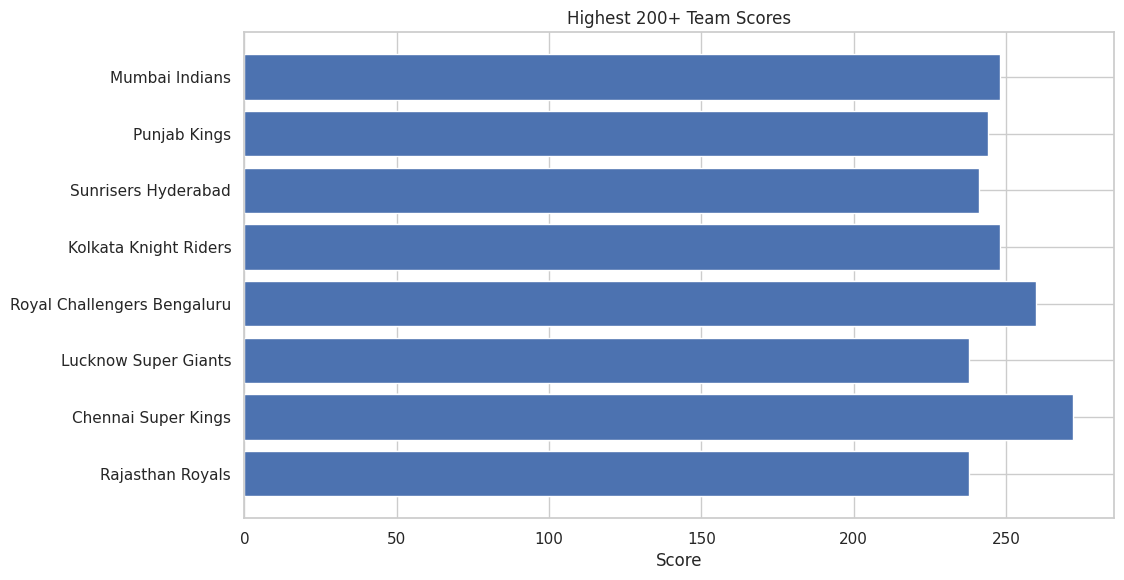

In [33]:
high_scoring_scores = pd.concat([
    high_scoring[["team1", "team1_score"]].rename(columns={"team1": "team", "team1_score": "score"}),
    high_scoring[["team2", "team2_score"]].rename(columns={"team2": "team", "team2_score": "score"})
])
high_scoring_scores = high_scoring_scores[high_scoring_scores["score"] >= 200]

top_high_scores = high_scoring_scores.sort_values("score", ascending=False).head(15)
plt.figure(figsize=(10,6))
plt.barh(top_high_scores["team"][::-1], top_high_scores["score"][::-1])
plt.title("Highest 200+ Team Scores")
plt.xlabel("Score")
plt.show()

## 10. Prepare Match + Ball Data

In [34]:
df = pd.merge(mat, dev.drop(columns=["season"]), on="match_id", how="left")
print("Merged data shape:", df.shape)
print(df.columns.tolist())

Merged data shape: (107019, 30)
['match_id', 'season', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin_type', 'result_margin', 'team1_score', 'team2_score', 'eliminator', 'umpire1', 'umpire2', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'bowler', 'batsman_runs', 'extra_runs', 'total_runs', 'is_wicket', 'dismissal_kind', 'player_dismissed']


In [35]:
print(df.isnull().sum().sort_values(ascending=False).head(15))

player_dismissed      100640
match_id                   0
city                       0
venue                      0
team1                      0
season                     0
toss_winner                0
toss_decision              0
winner                     0
result                     0
result_margin_type         0
result_margin              0
team1_score                0
team2                      0
team2_score                0
dtype: int64


In [36]:
season_runs = df.groupby("season")["total_runs"].sum().sort_index()
season_runs

season
2016    19703
2017    19975
2018    20533
2019    20332
2020    20037
2021    20355
2022    25419
2023    24627
Name: total_runs, dtype: int64

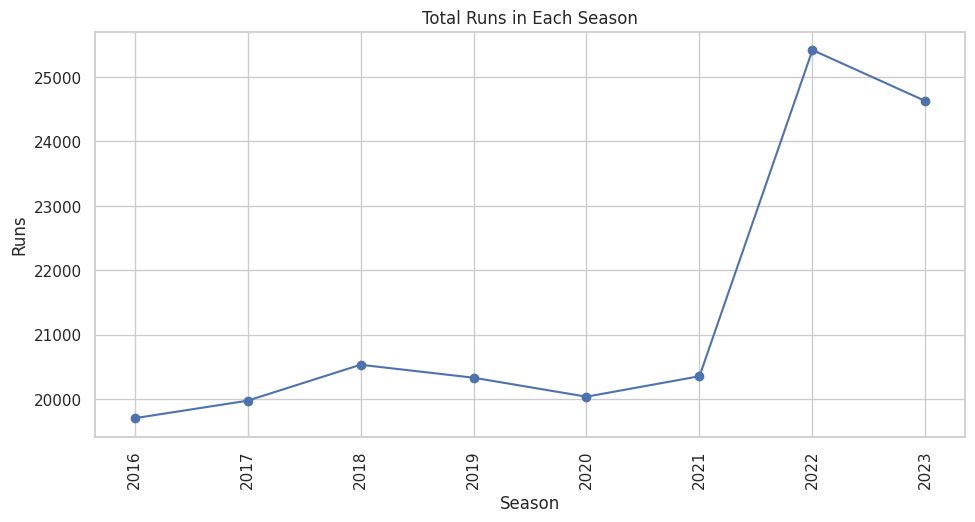

In [37]:
plt.figure(figsize=(10,5))
plt.plot(season_runs.index, season_runs.values, marker="o")
plt.title("Total Runs in Each Season")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.xticks(rotation=90)
plt.show()

## 11. Batting Overview

In [38]:
top_batsmen = dev.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(10)
top_batsmen

batsman
R Ghosh     3761
S Iyer      3695
A Ghosh     3482
A Thakur    3274
S Nair      2969
A Bose      2955
N Singh     2779
L Ellis     2754
C Walsh     2735
Y Bhatt     2715
Name: batsman_runs, dtype: int64

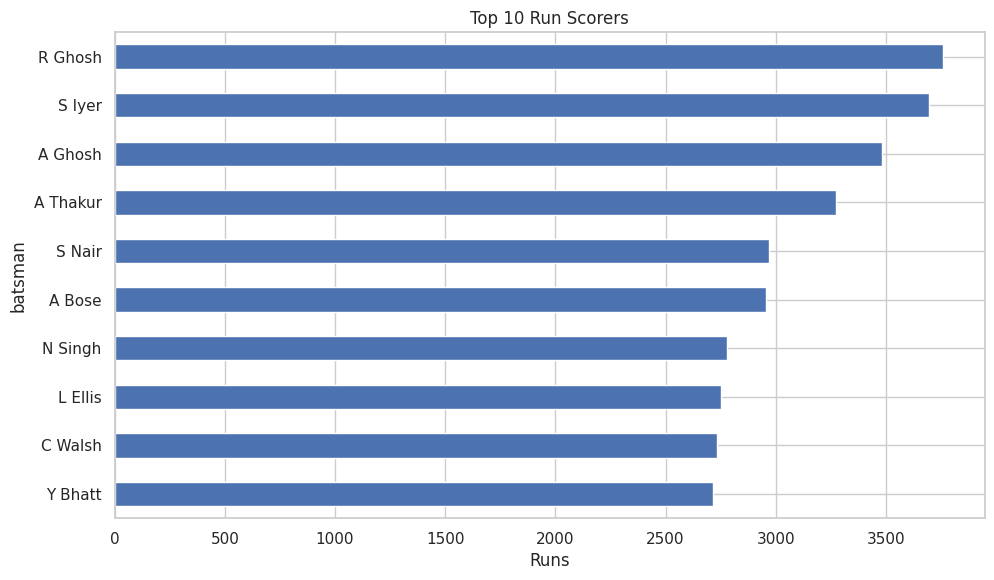

In [39]:
plt.figure(figsize=(10,6))
top_batsmen.sort_values().plot(kind="barh")
plt.title("Top 10 Run Scorers")
plt.xlabel("Runs")
plt.show()

In [40]:
batting_stats = dev.groupby("batsman").agg(
    balls=("ball", "count"),
    runs=("batsman_runs", "sum")
).sort_values("runs", ascending=False)
batting_stats["strike_rate"] = (batting_stats["runs"] / batting_stats["balls"] * 100).round(2)
batting_stats.head(10)

,balls,runs,strike_rate
batsman,,,
R Ghosh,2449,3761,153.57
S Iyer,2366,3695,156.17
A Ghosh,2236,3482,155.72
A Thakur,2140,3274,152.99
S Nair,1781,2969,166.70
A Bose,1766,2955,167.33
N Singh,1715,2779,162.04
L Ellis,1671,2754,164.81
C Walsh,1730,2735,158.09


In [41]:
def player_run_breakup(data, player):
    temp = data[data["batsman"] == player]
    result = {}
    for runs in [1, 2, 3, 4, 6]:
        result[f"runs_from_{runs}s"] = int((temp["batsman_runs"] == runs).sum() * runs)
    return pd.Series(result)

top_player = top_batsmen.index[0]
print("Run breakup for:", top_player)
player_run_breakup(dev, top_player)

Run breakup for: R Ghosh


runs_from_1s     542
runs_from_2s     388
runs_from_3s     231
runs_from_4s    1268
runs_from_6s    1332
dtype: int64

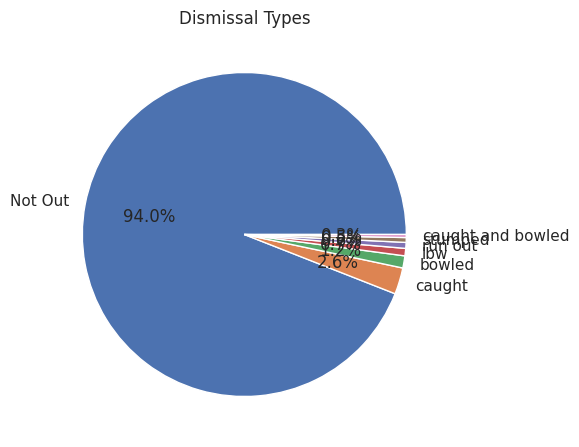

In [42]:
plt.figure(figsize=(10,5))
dismissals = dev["dismissal_kind"].value_counts()
dismissals.plot(kind="pie", autopct="%1.1f%%")
plt.title("Dismissal Types")
plt.ylabel("")
plt.show()

## 12. Bowling Overview

In [43]:
bowling_stats = dev.groupby("bowler").agg(
    runs_conceded=("total_runs", "sum"),
    balls=("ball", "count"),
    wickets=("is_wicket", "sum")
)
bowling_stats["economy"] = (bowling_stats["runs_conceded"] / (bowling_stats["balls"] / 6)).round(2)
bowling_stats = bowling_stats.sort_values("wickets", ascending=False)
bowling_stats.head(10)

,runs_conceded,balls,wickets,economy
bowler,,,,
A Kulkarni,4676,2836,180,9.89
A Pillai,3399,2231,139,9.14
K Reddy,2883,1800,131,9.61
R Joshi,3210,2088,130,9.22
A Nair,3683,2225,122,9.93
S Dutta,2905,1865,115,9.35
C Brooks,2258,1427,98,9.49
R Malhotra,2198,1424,98,9.26
K Nair,2233,1397,96,9.59


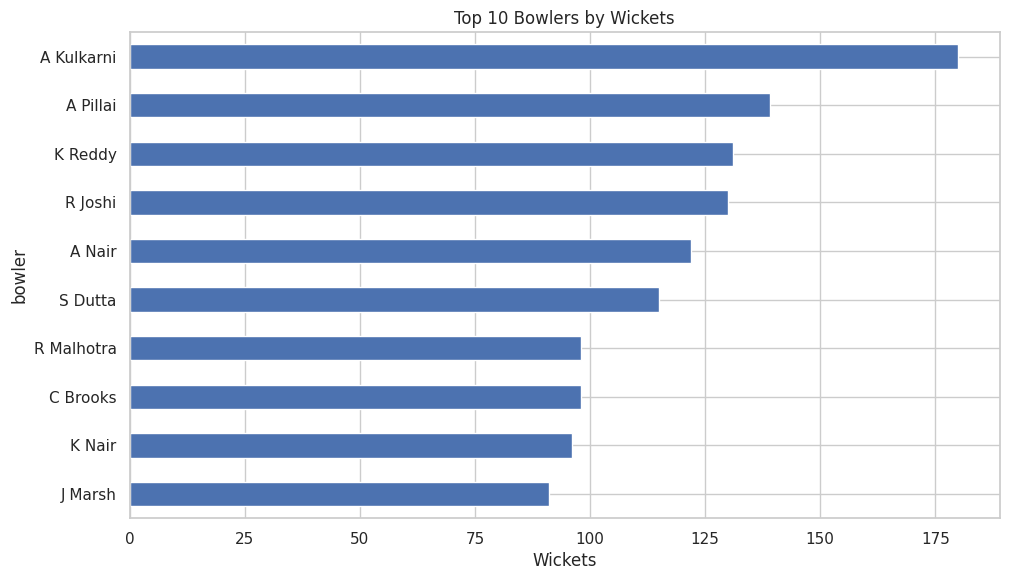

In [44]:
plt.figure(figsize=(10,6))
bowling_stats.head(10)["wickets"].sort_values().plot(kind="barh")
plt.title("Top 10 Bowlers by Wickets")
plt.xlabel("Wickets")
plt.show()

## 13. Orange Cap Winners by Season

In [45]:
orange_cap = dev.groupby(["season", "batsman"])["batsman_runs"].sum().reset_index()
orange_cap = orange_cap.loc[orange_cap.groupby("season")["batsman_runs"].idxmax()]
orange_cap = orange_cap.sort_values("season").reset_index(drop=True)
orange_cap.rename(columns={"batsman":"player", "batsman_runs":"runs"}, inplace=True)
orange_cap

,season,player,runs
0,2016,A Thakur,944
1,2017,N Singh,798
2,2018,A Bhatt,860
3,2019,S Nair,1118
4,2020,S Kulkarni,1082
5,2021,S Iyer,997
6,2022,Y Shetty,1230
7,2023,R Ghosh,1088


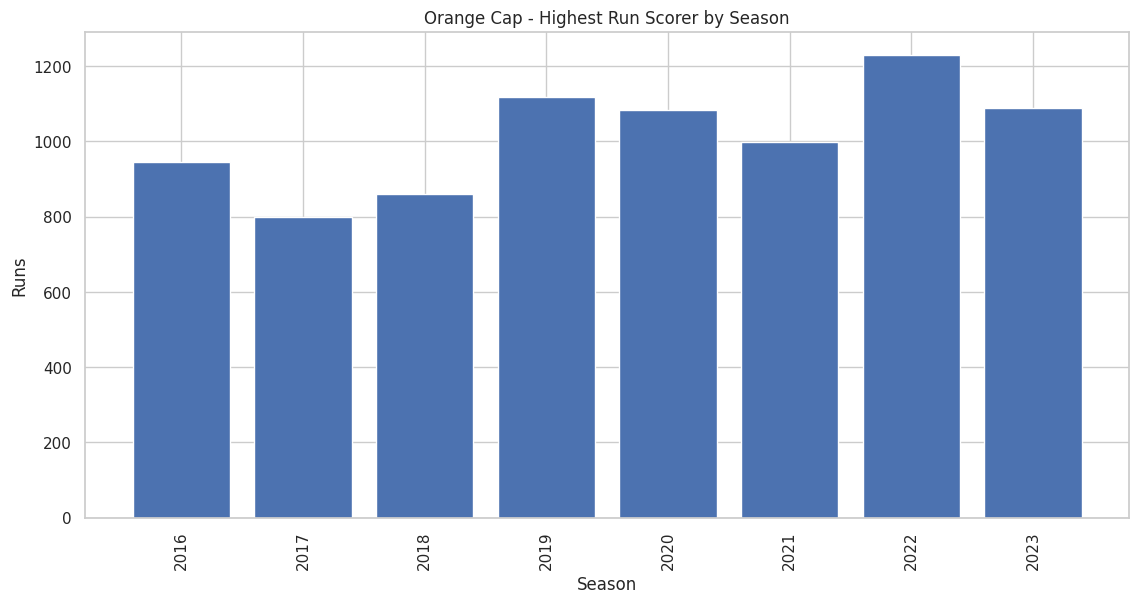

In [46]:
plt.figure(figsize=(12,6))
plt.bar(orange_cap["season"], orange_cap["runs"])
plt.title("Orange Cap - Highest Run Scorer by Season")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.xticks(rotation=90)
plt.show()

## 14. Purple Cap Winners by Season

In [47]:
valid_wickets = dev[dev["is_wicket"] == 1].copy()

# Exclude dismissals that should not normally be credited to the bowler
not_bowler_wickets = ["run out", "retired hurt", "obstructing the field", "retired out"]
valid_wickets = valid_wickets[~valid_wickets["dismissal_kind"].isin(not_bowler_wickets)]

purple_cap = valid_wickets.groupby(["season", "bowler"]).size().reset_index(name="wickets")
purple_cap = purple_cap.loc[purple_cap.groupby("season")["wickets"].idxmax()]
purple_cap = purple_cap.sort_values("season").reset_index(drop=True)
purple_cap

,season,bowler,wickets
0,2016,A Kulkarni,49
1,2017,K Nair,40
2,2018,P Mehta,34
3,2019,A Kulkarni,34
4,2020,D Marsh,39
5,2021,S Chauhan,38
6,2022,A Pillai,41
7,2023,C Harding,37


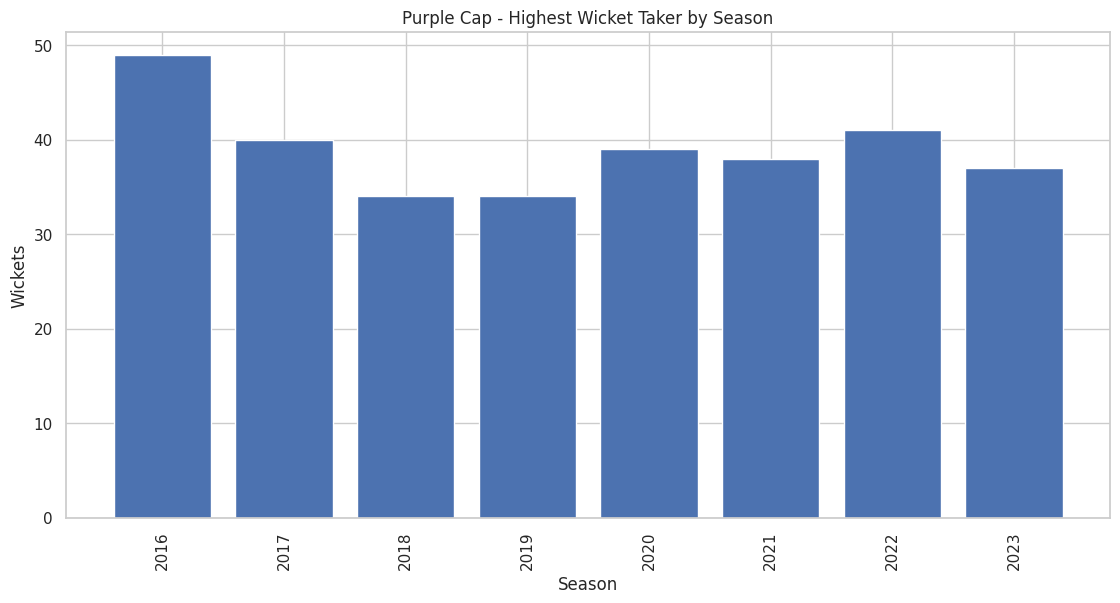

In [48]:
plt.figure(figsize=(12,6))
plt.bar(purple_cap["season"], purple_cap["wickets"])
plt.title("Purple Cap - Highest Wicket Taker by Season")
plt.xlabel("Season")
plt.ylabel("Wickets")
plt.xticks(rotation=90)
plt.show()

## 15. Player Comparison

In [49]:
def compare_batting_players(player1, player2):
    players = batting_stats.loc[batting_stats.index.intersection([player1, player2])].copy()
    return players[["runs", "balls", "strike_rate"]]

# Change these names to compare any two batsmen
compare_batting_players(top_batsmen.index[0], top_batsmen.index[1])

,runs,balls,strike_rate
batsman,,,
R Ghosh,3761,2449,153.57
S Iyer,3695,2366,156.17


In [50]:
def compare_bowling_players(player1, player2):
    players = bowling_stats.loc[bowling_stats.index.intersection([player1, player2])].copy()
    return players[["wickets", "economy", "balls"]]

top_bowlers = bowling_stats.head(2).index.tolist()
compare_bowling_players(top_bowlers[0], top_bowlers[1])

,wickets,economy,balls
bowler,,,
A Kulkarni,180,9.89,2836
A Pillai,139,9.14,2231


## 16. Team Head-to-Head Analysis

In [51]:
teams = sorted(pd.unique(pd.concat([mat["team1"], mat["team2"]]).dropna()))
team_wins = pd.DataFrame(0, index=teams, columns=teams)

for _, row in mat.dropna(subset=["winner"]).iterrows():
    if row["winner"] in team_wins.index:
        team_wins.loc[row["winner"], row["team1"]] += 1
        team_wins.loc[row["winner"], row["team2"]] += 1

team_wins

,Chennai Super Kings,Delhi Capitals,Gujarat Titans,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,Punjab Kings,Rajasthan Royals,Royal Challengers Bengaluru,Sunrisers Hyderabad
Chennai Super Kings,56,7,2,9,1,8,6,9,5,9
Delhi Capitals,8,53,1,8,2,4,6,5,10,9
Gujarat Titans,1,2,15,3,1,2,2,1,2,1
Kolkata Knight Riders,7,6,1,53,0,10,6,10,3,10
Lucknow Super Giants,2,1,2,2,16,2,3,3,0,1
Mumbai Indians,8,11,2,5,1,56,10,7,6,6
Punjab Kings,9,10,2,8,1,6,58,7,6,9
Rajasthan Royals,6,10,2,4,1,8,9,53,5,8
Royal Challengers Bengaluru,10,5,2,12,3,9,9,11,71,10
Sunrisers Hyderabad,5,6,2,5,1,9,5,6,6,45


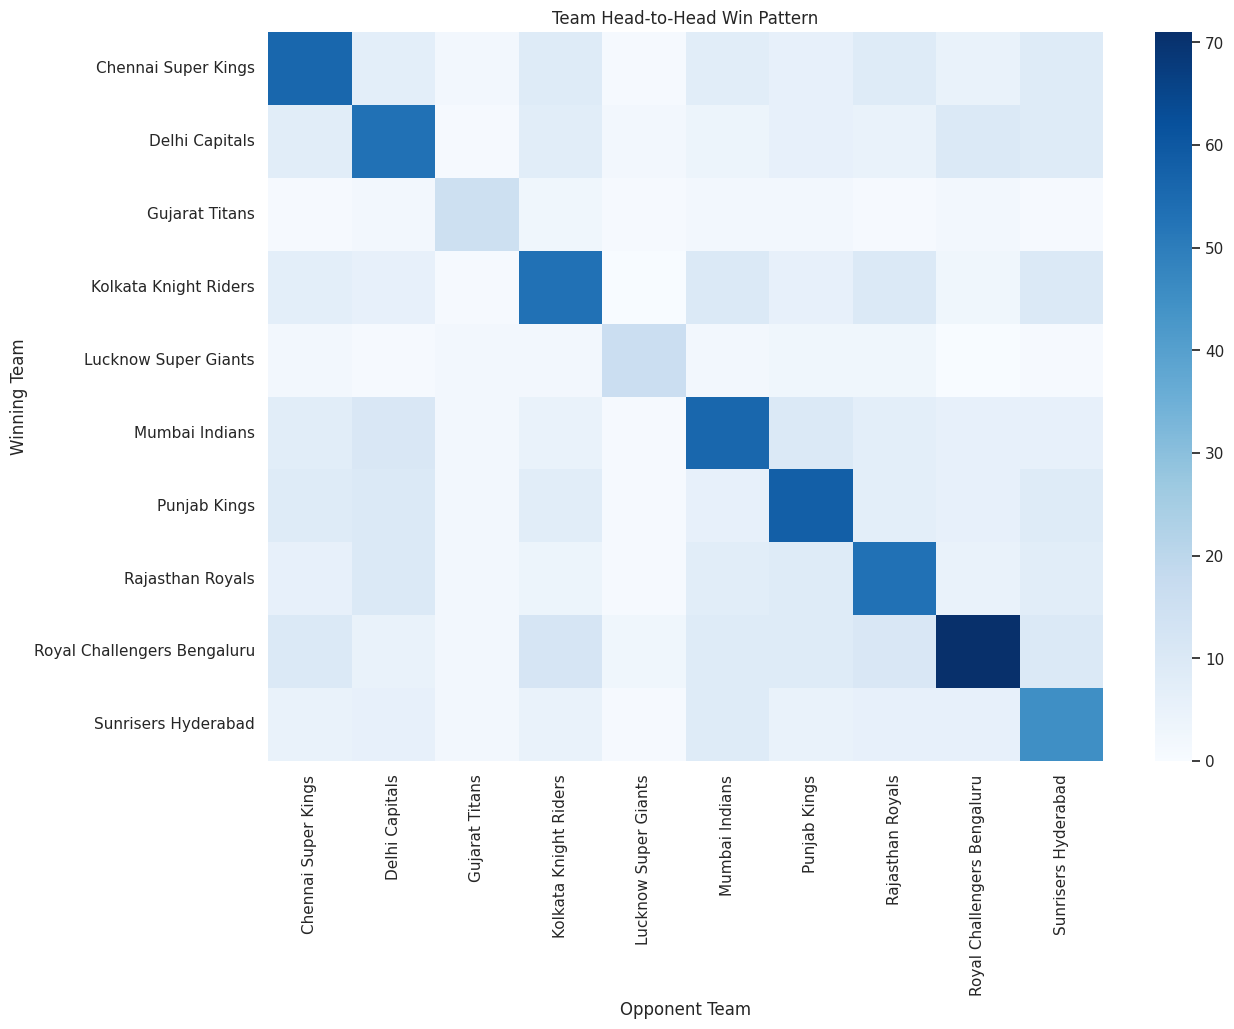

In [52]:
plt.figure(figsize=(12,9))
sns.heatmap(team_wins, annot=False, cmap="Blues")
plt.title("Team Head-to-Head Win Pattern")
plt.xlabel("Opponent Team")
plt.ylabel("Winning Team")
plt.show()

## 17. Winner Prediction Using Pandas and NumPy

In [53]:
# Simple historical prediction model - no machine learning library is used.
# It uses overall win rate, head-to-head win rate and recent form.

def team_win_rate(data, team):
    played = data[(data["team1"] == team) | (data["team2"] == team)]
    wins = (played["winner"] == team).sum()
    return wins / len(played) if len(played) else 0

def head_to_head_rate(data, team1, team2):
    h2h = data[((data["team1"] == team1) & (data["team2"] == team2)) |
               ((data["team1"] == team2) & (data["team2"] == team1))]
    if len(h2h) == 0:
        return 0.5
    return (h2h["winner"] == team1).sum() / len(h2h)

def predict_winner(data, team1, team2):
    form1 = team_win_rate(data, team1)
    form2 = team_win_rate(data, team2)
    h2h1 = head_to_head_rate(data, team1, team2)

    score1 = 0.6 * form1 + 0.4 * h2h1
    score2 = 0.6 * form2 + 0.4 * (1 - h2h1)

    winner = team1 if score1 >= score2 else team2
    return pd.Series({
        "team1": team1,
        "team2": team2,
        "team1_score": round(score1, 3),
        "team2_score": round(score2, 3),
        "predicted_winner": winner
    })

# Example prediction
predict_winner(mat, mat.iloc[-1]["team1"], mat.iloc[-1]["team2"])

team1                   Rajasthan Royals
team2               Lucknow Super Giants
team1_score                        0.384
team2_score                        0.656
predicted_winner    Lucknow Super Giants
dtype: object

## 18. Prediction Accuracy

In [54]:
# Historical holdout test:
# use the first 80% of matches as history and the last 20% as test matches.

split_point = int(len(mat) * 0.80)
train = mat.iloc[:split_point].copy()
test = mat.iloc[split_point:].copy()

predictions = []
actuals = []

for _, row in test.iterrows():
    if pd.isna(row["winner"]) or row["winner"] == "No Result":
        continue

    p = predict_winner(train, row["team1"], row["team2"])["predicted_winner"]
    predictions.append(p)
    actuals.append(row["winner"])

accuracy = (np.array(predictions) == np.array(actuals)).mean() * 100
print("Prediction accuracy:", round(accuracy, 2), "%")

Prediction accuracy: 46.88 %


## 19. Prediction by Year

In [55]:
def predict_by_year(data, season):
    season_data = data[data["season"] == str(season)]
    if len(season_data) == 0:
        return pd.DataFrame()

    rows = []
    for _, row in season_data.iterrows():
        if pd.isna(row["winner"]) or row["winner"] == "No Result":
            continue
        p = predict_winner(data[data["season"].astype(int) < int(season)],
                           row["team1"], row["team2"])
        rows.append({
            "season": season,
            "team1": row["team1"],
            "team2": row["team2"],
            "predicted_winner": p["predicted_winner"],
            "actual_winner": row["winner"]
        })
    result = pd.DataFrame(rows)
    if len(result):
        result["correct"] = result["predicted_winner"] == result["actual_winner"]
    return result

# Example: inspect one season
predict_by_year(mat, mat["season"].astype(int).max()).head(10)

,season,team1,team2,predicted_winner,actual_winner,correct
0,2023,Chennai Super Kings,Gujarat Titans,Chennai Super Kings,Gujarat Titans,False
1,2023,Chennai Super Kings,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,True
2,2023,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,True
3,2023,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,Mumbai Indians,False
4,2023,Sunrisers Hyderabad,Gujarat Titans,Sunrisers Hyderabad,Sunrisers Hyderabad,True
5,2023,Mumbai Indians,Punjab Kings,Mumbai Indians,Mumbai Indians,True
6,2023,Mumbai Indians,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,True
7,2023,Kolkata Knight Riders,Gujarat Titans,Kolkata Knight Riders,Gujarat Titans,False
8,2023,Mumbai Indians,Gujarat Titans,Mumbai Indians,Mumbai Indians,True
9,2023,Royal Challengers Bengaluru,Lucknow Super Giants,Royal Challengers Bengaluru,Royal Challengers Bengaluru,True


## 20. Interactive Plotly Visualization

In [56]:
interactive_team_wins = mat["winner"].value_counts().head(10).reset_index()
interactive_team_wins.columns = ["team", "wins"]

fig = go.Figure(
    data=[go.Bar(
        x=interactive_team_wins["team"],
        y=interactive_team_wins["wins"],
        text=interactive_team_wins["wins"],
        textposition="auto"
    )]
)

fig.update_layout(
    title="Top 10 IPL Teams by Wins",
    xaxis_title="Team",
    yaxis_title="Wins"
)

py.iplot(fig)


## 21. Key Insights

In [57]:
print("Key insights from the IPL dataset")
print("1. Most successful teams can be identified from season-wise and overall win counts.")
print("2. Toss decisions can be compared with match outcomes to understand toss advantage.")
print("3. High-scoring matches are identified using team scores of 200 or more.")
print("4. Orange Cap and Purple Cap analysis shows the leading batter and bowler for each season.")
print("5. Batting analysis compares runs and strike rate.")
print("6. Bowling analysis compares wickets and economy.")
print("7. The winner prediction module uses historical statistics with Pandas and NumPy only.")
print("8. Visualizations make team, player and season trends easier to understand.")

Key insights from the IPL dataset
1. Most successful teams can be identified from season-wise and overall win counts.
2. Toss decisions can be compared with match outcomes to understand toss advantage.
3. High-scoring matches are identified using team scores of 200 or more.
4. Orange Cap and Purple Cap analysis shows the leading batter and bowler for each season.
5. Batting analysis compares runs and strike rate.
6. Bowling analysis compares wickets and economy.
7. The winner prediction module uses historical statistics with Pandas and NumPy only.
8. Visualizations make team, player and season trends easier to understand.
